Credit Card Fraud Detection 

In [107]:
## IMPORTING ALL LIBRARY
import numpy as np

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')


In [108]:
## LOADING THE DATASET

card=pd.read_csv(r"C:\Users\Isha\Downloads\DA_PROJECTS\ML_PROJECT\CREDIT_ CARD_FRAUD_ DETECTION\creditcard.csv")

In [109]:
## CHECKING THE DATASET
card.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [110]:
##CHECKING LAST 5 ROWS OF THE DATASET
card.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [111]:
#CHECKING STATISTICAL INFORMATION OF THE DATASET
card.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [112]:
#CHECKING THE SHAPE OF THE DATASET
card.shape

(284807, 31)

In [113]:
#CHECKING FOR MISSING VALUES
card.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [114]:
## INFORMATION ABOUT THE DATASET
card.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [115]:
#DISTRIBUTION OF FRAUD AND NON-FRAUD TRANSACTIONS
card['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [116]:
##DISTRIBUTION OF FRAUD AND NON-FRAUD TRANSACTIONS IN PERCENTAGE
card['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

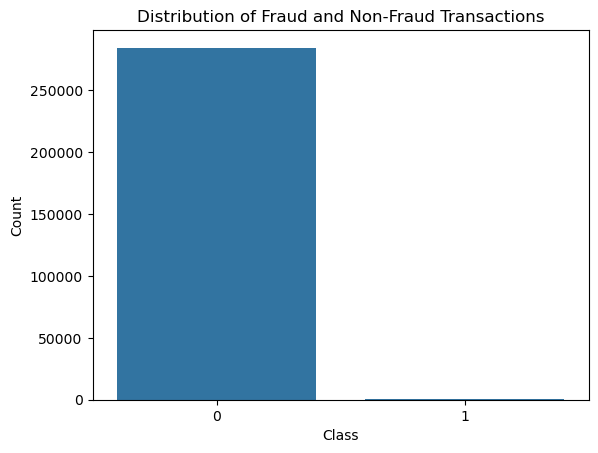

In [117]:
##DISTRIBUTION OF FRAUD AND NON-FRAUD TRANSACTIONS ON GRAPH
sns.countplot(x='Class',data=card)
plt.title('Distribution of Fraud and Non-Fraud Transactions')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

## THIS DATA IS UNBALANCED DATASET. SO WE NEED TO BALANCE THE DATASET. WE CAN USE OVERSAMPLING OR UNDERSAMPLING TECHNIQUE. HERE WE ARE USING UNDERSAMPLING TECHNIQUE.
# 0-NON-FRAUD TRANSACTIONS
# 1-FRAUD TRANSACTIONS

In [118]:
##SEPARATING FRAUD AND NON-FRAUD TRANSACTIONS
legit=card[card.Class==0]
fraud=card[card.Class==1]


In [119]:
## CHECKING THE DATASET
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [120]:
## statistical information of the legit transactions
legit.Amount.describe()



count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [121]:

## statistical information of the fraud transactions
fraud.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [122]:
#COMPARING THE TWO TRANSACTIONS
card.groupby('Class').mean()
# we do the beccause the mean of the fraud transction is lower than the mean of the legit transaction. so we can say that the fraud transaction is less than the legit transaction.

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


UNDER SAMPLING 

In [123]:
## WE WILL NOW UNDER SAMPLE THE DATASET TO BALANCE THE DATASET AND DIVIDE IN EQUAL PARTS OF FRAUD AND NON-FRAUD TRANSACTIONS
legit_sample=legit.sample(n=492)

In [124]:
##COMBINING THE TWO DATASETS
combined_data = pd.concat([legit_sample, fraud], axis=0)

In [125]:
##checking the shape of the dataset
combined_data.shape

(984, 31)

In [126]:
## CHECKING THE DATASET
combined_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
74209,55471.0,-0.561172,1.204750,1.858691,1.989665,0.122007,0.102597,0.750778,0.071015,-1.194483,...,-0.010830,0.020300,-0.040887,0.529905,-0.457644,-0.248844,0.025717,0.146441,27.48,0
238636,149751.0,2.098021,-1.053820,-1.781526,-1.178713,-0.156826,-0.354913,-0.414387,-0.177445,-0.640696,...,0.476164,1.187009,-0.217617,-1.099754,0.250972,0.121450,-0.054236,-0.073508,90.75,0
50078,44337.0,-1.724131,1.045889,-0.174343,0.264806,-0.335705,-0.582383,-0.313930,1.076248,0.414337,...,-0.038348,0.100656,0.052637,-0.037068,0.246578,0.513025,0.202674,-0.139775,25.00,0
187327,127482.0,-0.467195,0.286561,1.120410,-1.240496,-0.264067,-0.561563,0.004111,-0.287075,-1.072651,...,0.330295,0.950026,-0.263120,-0.007432,-0.266473,-0.048894,-0.237067,0.184166,5.00,0
111196,72136.0,0.906546,-0.598193,0.625900,1.506847,-0.282228,1.479545,-0.730364,0.497966,0.109834,...,0.131377,0.112813,-0.267676,-1.303479,0.180414,1.123826,-0.055676,0.014915,145.38,0


In [127]:
## CHECKING THE DATASET
combined_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1
281674,170348.0,1.991976,0.158476,-2.583441,0.408670,1.151147,-0.096695,0.223050,-0.068384,0.577829,...,-0.164350,-0.295135,-0.072173,-0.450261,0.313267,-0.289617,0.002988,-0.015309,42.53,1


In [128]:
## counting the number of fraud and non-fraud transactions in the dataset
combined_data['Class'].value_counts()

Class
0    492
1    492
Name: count, dtype: int64

In [129]:
## GROUPING THE DATASET BY CLASS AND TAKING THE MEAN OF EACH COLUMN
combined_data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94498.250000,0.032712,-0.106685,-0.030395,0.031155,0.021934,-0.073913,-0.074179,0.065242,-0.004185,...,-0.057564,0.009774,0.000466,0.006825,0.000918,-0.014392,-0.016611,0.034766,-0.039171,71.582053
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


SPLITING THE DATA INTO TRAIN AND TEST

In [130]:
x=combined_data.drop('Class',axis=1)
y=combined_data['Class']

In [131]:
print(x)

            Time        V1        V2        V3        V4        V5        V6  \
74209    55471.0 -0.561172  1.204750  1.858691  1.989665  0.122007  0.102597   
238636  149751.0  2.098021 -1.053820 -1.781526 -1.178713 -0.156826 -0.354913   
50078    44337.0 -1.724131  1.045889 -0.174343  0.264806 -0.335705 -0.582383   
187327  127482.0 -0.467195  0.286561  1.120410 -1.240496 -0.264067 -0.561563   
111196   72136.0  0.906546 -0.598193  0.625900  1.506847 -0.282228  1.479545   
...          ...       ...       ...       ...       ...       ...       ...   
279863  169142.0 -1.927883  1.125653 -4.518331  1.749293 -1.566487 -2.010494   
280143  169347.0  1.378559  1.289381 -5.004247  1.411850  0.442581 -1.326536   
280149  169351.0 -0.676143  1.126366 -2.213700  0.468308 -1.120541 -0.003346   
281144  169966.0 -3.113832  0.585864 -5.399730  1.817092 -0.840618 -2.943548   
281674  170348.0  1.991976  0.158476 -2.583441  0.408670  1.151147 -0.096695   

              V7        V8        V9  .

In [132]:
print(y)

74209     0
238636    0
50078     0
187327    0
111196    0
         ..
279863    1
280143    1
280149    1
281144    1
281674    1
Name: Class, Length: 984, dtype: int64


In [133]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2,stratify=y)

MODEL TRAINING

LinearRegression()

In [134]:
lr=LinearRegression()

In [135]:
## Fitting the model
lr.fit(x_train,y_train)

LinearRegression()

MODEL EVALUATION

In [136]:
## Model Evaluation
Predictions=lr.predict(x_test)

In [139]:
x_train_pred=lr.predict(x_train)
x_test_pred=lr.predict(x_test)

In [141]:
training_data_accuracy=r2_score(y_train,x_train_pred)
print('R2 score of training data:',training_data_accuracy)

R2 score of training data: 0.6722689745313222


In [142]:
test_data_accuracy=r2_score(y_test,x_test_pred)
print('R2 score of test data:',test_data_accuracy)  

R2 score of test data: 0.5724960523850677


In [137]:
## ACCURACY SCORE



r2 = r2_score(y_test, Predictions)
mae = mean_absolute_error(y_test, Predictions)
mse = mean_squared_error(y_test, Predictions)

print("R² Score:", r2)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)


R² Score: 0.5724960523850677
Mean Absolute Error: 0.26050568424769166
Mean Squared Error: 0.10687323300677869


SVC

In [143]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [144]:
## MODEL BUILDING USING SVM
svc=SVC(kernel='linear', random_state=42,gamma='scale',C=1)

In [145]:
# Training the SVM model
svc.fit(x_train, y_train)

SVC(C=1, kernel='linear', random_state=42)

In [146]:
## predicting the test data
svc_predictions = svc.predict(x_test)

In [147]:
# CLASSIFICATION REPORT
print(classification_report(y_test, svc_predictions))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92        99
           1       1.00      0.82      0.90        98

    accuracy                           0.91       197
   macro avg       0.92      0.91      0.91       197
weighted avg       0.92      0.91      0.91       197



In [150]:
# CONFUSION MATRIX
print(confusion_matrix(y_test, svc_predictions))

[[99  0]
 [18 80]]


In [152]:
##Accuracy Score
accuracy = accuracy_score(y_test, svc_predictions)
print("Accuracy:", accuracy)

Accuracy: 0.9086294416243654
